In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU if available
device

device(type='cuda', index=0)

In [13]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 3

32033 words, 26 unique characters


In [14]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 3]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 3]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 3]) 	Y: torch.Size([22866])


In [15]:
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g, device=device)     #  27 characters, 2 dimensions each
W1 = torch.randn((6,100), generator=g, device=device)   #   3 characters times 2 embedding values as inputs to 100 neurons
b1 = torch.randn((100), generator=g, device=device)     # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g, device=device)  # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g, device=device)      #  27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2] # Cluster all parameters into one structure

print(sum(p.nelement() for p in parameters), 'parameters') # Network stays the same, so same number of parameters

# Allowing for gradient accumulation
for p in parameters:
    p.requires_grad = True

3481 parameters


In [16]:
# For the 32 input dataset, we had used 1000 epochs
# Now, for the much larger dataset, we can reduce this to 10 epochs
lossi = []
stepi = []
i = 0
for i in range(4000):
    # mini-batch construction -> 32 indices of 3-dimensional character index vectors within X
    ix = torch.randint(0, Xtr.shape[0], (32,))

    ## Forward-Pass
    emb = C[Xtr[ix]] # (32, 3, 2), a single batch, Xtr[ix] grabs only the 32 indices, C then grabs the 2-dimensional vectors for each of the 3 characters for the current of the 32 triplets
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
   
    loss = F.cross_entropy(logits, Ytr[ix])# Ytr[ix] grabs the 32 expected output indices for the current batch (very elegant)
    
    lossi.append(loss.item())
    stepi.append(i)
    print(loss.item())

    # Learning rate decay to more closely approach the minimum
    lr = 0.1 if i < 30000 else 0.01    

    ## Backward-Pass
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    # Update
    for p in parameters:
        p.data += -lr * p.grad

16.16318130493164
13.028316497802734
14.14450740814209
10.848899841308594
10.30600643157959
12.826309204101562
10.616945266723633
10.024436950683594
12.227203369140625
10.814921379089355
8.444974899291992
10.011216163635254
10.488099098205566
9.290934562683105
10.702882766723633
9.534875869750977
7.771172523498535
6.697157859802246
7.786076068878174
8.164402961730957
8.70076847076416
7.401578426361084
8.13273811340332
7.3216047286987305
8.259275436401367
6.643198013305664
6.912731170654297
5.986525535583496
6.8761210441589355
6.126641750335693
6.951780319213867
7.809865474700928
7.485123157501221
6.253639221191406
5.247673511505127
6.025484085083008
5.200480937957764
6.628118515014648
4.673548698425293
4.372346878051758
6.53203821182251
4.70492696762085
4.338870048522949
5.195990562438965
6.904006004333496
4.985538005828857
5.916449069976807
4.774759769439697
4.56436824798584
5.233847141265869
5.034184455871582
3.8352670669555664
4.31098747253418
6.05942964553833
4.468153953552246
4.08

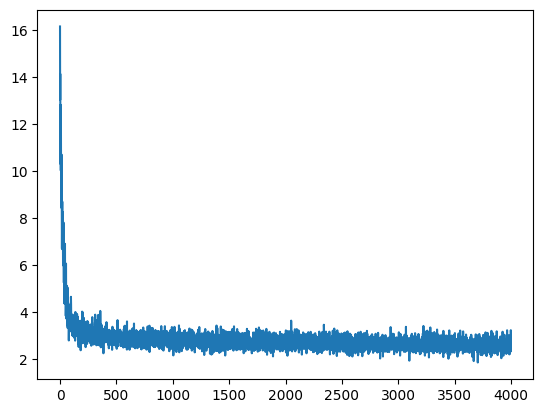

In [17]:
plt.plot(stepi, lossi);

In [18]:
# Validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.649470567703247


In [19]:
# Test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
print(loss.item())

2.6545658111572266


In [20]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out))

bbretsynezerekenrensarvyorerslenereidenomerehhebinreygrppngewey.
tosfenetetarelooniearstttastennogendynanrahrann.
jerlana.
uorga.
karee.
vemaekavorsay.
kavengpngannexcezeregierren.
saberle.
ackera.
merdemalganduyanlay.
rge.
norsonmensr.
paellerisetsoeeley.
jasrnenah.
jarha.
vanarkeseynaperesfikeryman.
kalira.
mesilny.
berusakevekezarviysobreeree.
aolyinan.
